## Data Preprocessing & Feature Engineering for Machine Learning (Housing Dataset)

__Features__:

* **longitude:**  geographic coordinate (district´s east-west position)
* **latitude:**  geographic coordinate (district´s north-south position)
* **housing_median_age:** median age of houses in district
* **total_rooms** Sum of all rooms in district
* **total_bedrooms** Sum of all bedrooms in district
* **population:** total population in district
* **households:** total households in district
* **median_income:** median household income in district 
* **median_house_value:** median house value in district
* **ocean_proximity:** District´s proximity to the ocean

In [199]:
import numpy as np

In [200]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_columns = 20

In [201]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

## Data Import and first Inspection

__Import__ the housing dataset (housing.csv) and __inspect__.

In [202]:
df = pd.read_csv('housing.csv')

In [203]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.00,880.00,129.00,322.00,126.00,8.33,452600.00,NEAR BAY
1,-122.22,37.86,21.00,7099.00,1106.00,2401.00,1138.00,8.30,358500.00,NEAR BAY
2,-122.24,37.85,52.00,1467.00,190.00,496.00,177.00,7.26,352100.00,NEAR BAY
3,-122.25,37.85,52.00,1274.00,235.00,558.00,219.00,5.64,341300.00,NEAR BAY
4,-122.25,37.85,52.00,1627.00,280.00,565.00,259.00,3.85,342200.00,NEAR BAY


In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [205]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


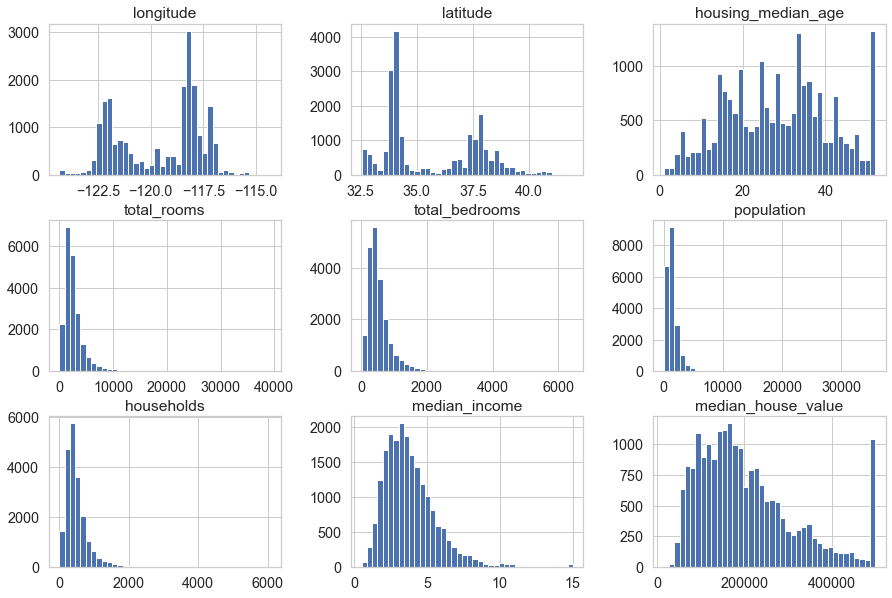

In [206]:
df.hist(figsize = (15,10), bins = 40)
plt.show()

## Data Cleaning and Creating additional Features

__Drop__ all rows with missing values.

In [207]:
df.dropna(inplace = True)

In [208]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

__Add__ the additional Feature __"rooms_per_household"__.

In [209]:
df['rooms_per_household'] = df.total_rooms.div(df.households)
df.rooms_per_household

0       6.98
1       6.24
2       8.29
3       5.82
4       6.28
        ... 
20635   5.05
20636   6.11
20637   5.21
20638   5.33
20639   5.25
Name: rooms_per_household, Length: 20433, dtype: float64

__Add__ the additional Feature __"population_per_household"__.

In [210]:
df['population_per_household'] = df.population.div(df.households)
df.population_per_household

0       2.56
1       2.11
2       2.80
3       2.55
4       2.18
        ... 
20635   2.56
20636   3.12
20637   2.33
20638   2.12
20639   2.62
Name: population_per_household, Length: 20433, dtype: float64

__Add__ the additional Feature __"bedrooms_per_household"__.

In [211]:
df['bedrooms_per_household'] = df.total_bedrooms.div(df.households)
df.bedrooms_per_household

0       1.02
1       0.97
2       1.07
3       1.07
4       1.08
        ... 
20635   1.13
20636   1.32
20637   1.12
20638   1.17
20639   1.16
Name: bedrooms_per_household, Length: 20433, dtype: float64

## Which Factors influence House Prices?

__Calculate__ the __Correlation__ between "median_house_value" and all features. Which factors seems to influence house prices/values?

In [212]:
corr = df.corr().median_house_value.sort_values()
corr

latitude                   -0.14
bedrooms_per_household     -0.05
longitude                  -0.05
population                 -0.03
population_per_household   -0.02
total_bedrooms              0.05
households                  0.06
housing_median_age          0.11
total_rooms                 0.13
rooms_per_household         0.15
median_income               0.69
median_house_value          1.00
Name: median_house_value, dtype: float64

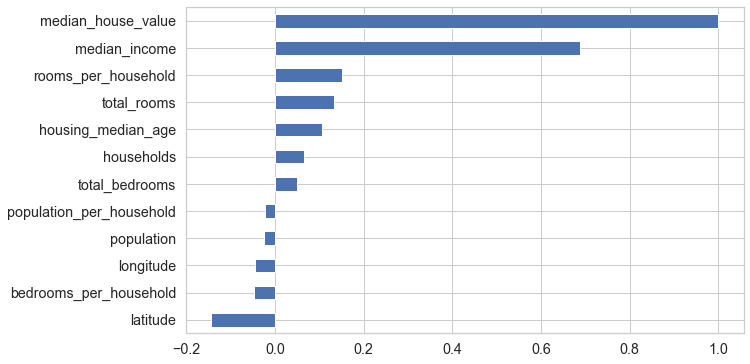

In [213]:
corr.plot.barh(figsize = (10,6))
plt.show()

__Create__ a Seaborn Regression plot with income on the x-axis and house value on the y-axis.

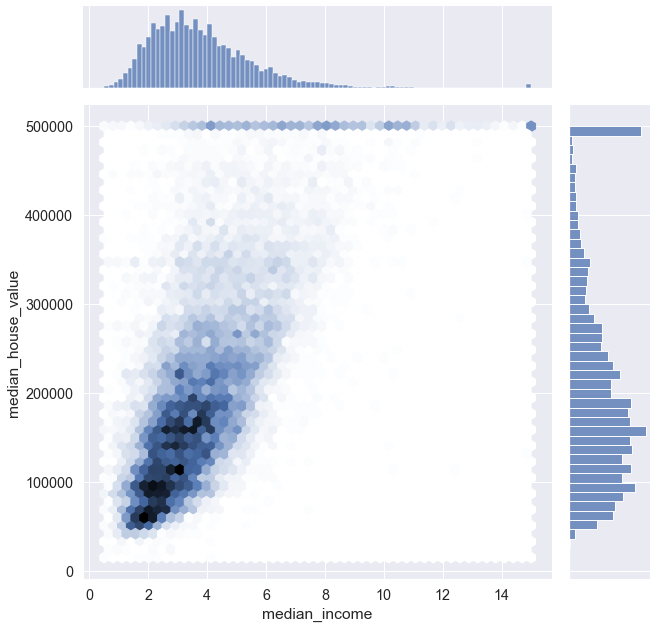

In [214]:
sns.set(font_scale = 1.3)
sns.jointplot(x = 'median_income', y = 'median_house_value', data = df, kind = 'hex', height = 9)
plt.show()

__Create__ the  __scatterplot__ with:
- longitude on x-axis
- latitude on y-axis
- size (s) of data points determined by population
- color (c) of data points determined by median_house_value

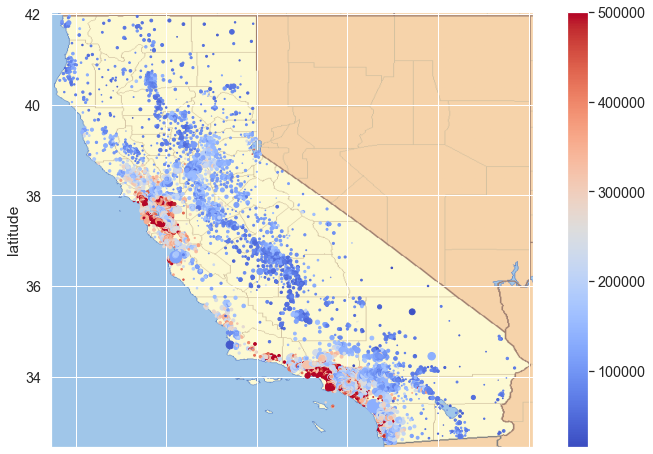

In [215]:
import matplotlib.image as mpimg
california_img = mpimg.imread('california.png')

df.plot(kind = 'scatter',x = 'longitude', y = 'latitude',
                s = df.population/200, c = df.median_house_value, cmap = 'coolwarm', figsize = (12,8))
plt.imshow(california_img, extent = [-124.55, -113.90, 32.45, 42.05])
plt.show()

## Advanced Explanatory Data Analyis with Seaborn

__Add__ the additional column __"income_cat"__ with the following income categories:
- lowest 25% -> "Low"
- 25th to 50th percentile -> "Below_Average"
- 50th to 75th percentile -> "Above_Average"
- 75th to 95th percentile -> "High"
- Above 95th percentile -> "Very High"

In [216]:
df['income_cat'] = pd.qcut(x = df.median_income, q = [0, 0.25, 0.5, 0.75, 0.95, 1],
        labels = ['Low', 'Below_Average', 'Above_Average', 'High', 'Very_High'] )

In [217]:
df['income_cat']

0            Very_High
1            Very_High
2                 High
3                 High
4        Above_Average
             ...      
20635              Low
20636              Low
20637              Low
20638              Low
20639              Low
Name: income_cat, Length: 20433, dtype: category
Categories (5, object): ['Low' < 'Below_Average' < 'Above_Average' < 'High' < 'Very_High']

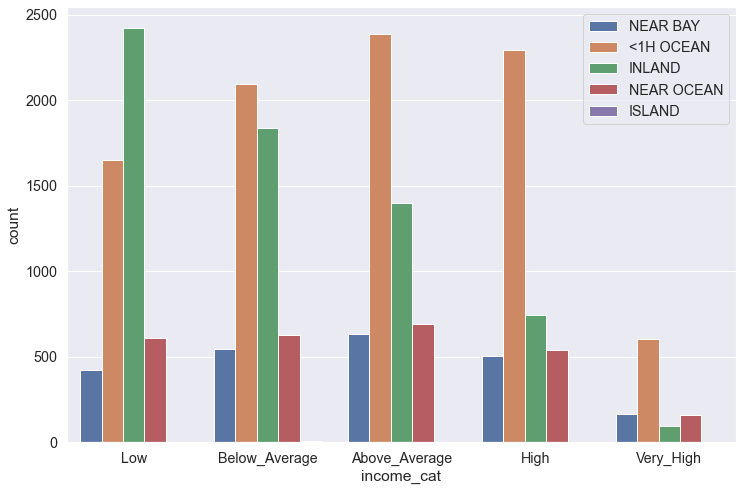

In [218]:
plt.figure(figsize = (12,8))
sns.countplot(x = 'income_cat', data = df, hue = 'ocean_proximity')
plt.legend(loc = 1)
plt.show()

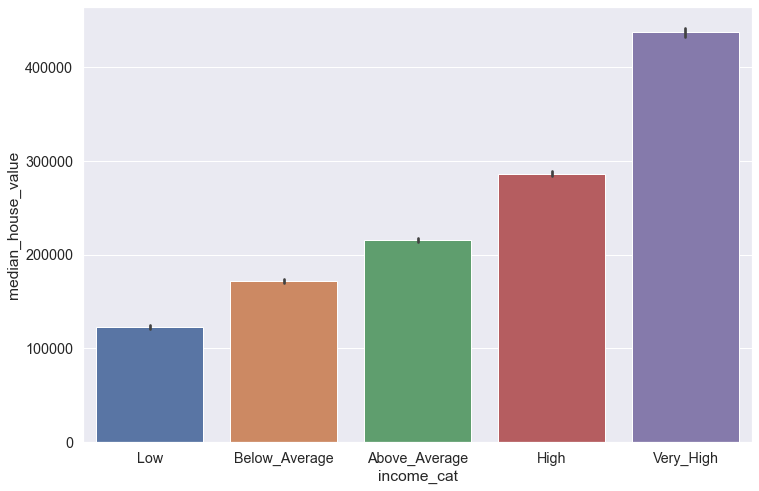

In [219]:
plt.figure(figsize =  (12,8))
sns.barplot(x = 'income_cat', y = 'median_house_value', data = df)
plt.show()

__Create__ Seaborn __Heatmap__ with mean house values for all combinations of income_cat & ocean_proximity.

In [220]:
hm_df = df.groupby(['income_cat', 'ocean_proximity']).median_house_value.mean().unstack().drop('ISLAND', axis = 1)
hm_df

ocean_proximity,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN
income_cat,,,,
Low,161337.08,84820.63,155122.05,148027.83
Below_Average,197236.01,115124.09,220196.18,208665.19
Above_Average,232278.36,147846.89,261965.25,255293.81
High,292208.77,208095.57,322566.03,337446.23
Very_High,439784.24,347571.74,451015.08,468739.72


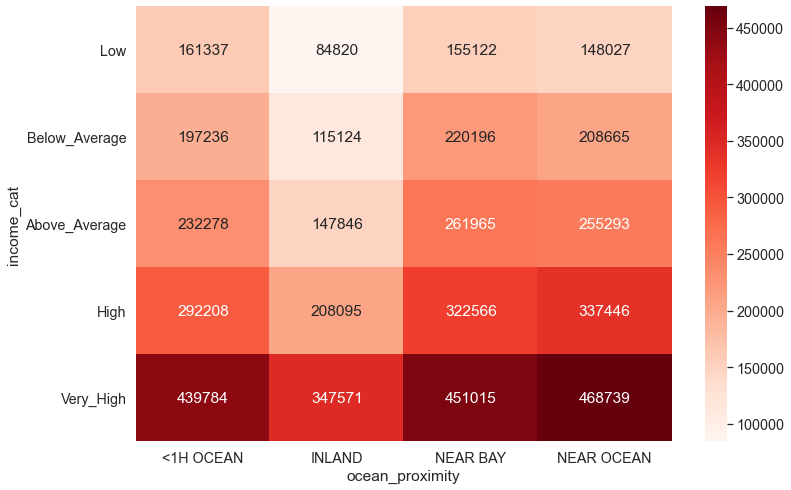

In [221]:
plt.figure(figsize = (12,8))
sns.heatmap(hm_df.astype('int'), annot = True, fmt = "d", cmap = 'Reds')
plt.show()

## Feature Engineering

In [222]:
dummies = pd.get_dummies(data = df[['ocean_proximity', 'income_cat']])
df_copy = df.drop(['income_cat', 'ocean_proximity', 'median_house_value'], axis = 1, inplace = False).copy()

In [223]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df_copy)
scaled = scaler.transform(df_copy)
df_normalized = pd.DataFrame(data = scaled, columns = df_copy.columns)

In [224]:
df_normalized.reset_index(drop = True, inplace = True)
dummies.reset_index(drop = True, inplace = True)
X = pd.concat([df_normalized, dummies], axis = 1)
y = df.median_house_value

## Splitting the Data into Train and Test Set

In [225]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

## Training the ML Model (Random Forest Regressor)

In [226]:
from sklearn.ensemble import RandomForestRegressor
model  = RandomForestRegressor(n_estimators = 500, max_depth = 100)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

## Evaluating the Model on the Test Set

In [227]:
from sklearn.metrics import mean_squared_error

In [228]:
mse = mean_squared_error(y_test, predictions)
mse

2485213933.403024

In [229]:
rmse = np.sqrt(mse)
rmse

49851.92005733605

In [230]:
pd.DataFrame(data = {'Predictions': predictions, 'True': y_test})

,Predictions,True
16676,269365.06,245900.00
8457,241838.41,235400.00
258,106188.80,94800.00
9247,54014.20,48000.00
6857,297722.01,301100.00
...,...,...
232,266771.23,263400.00
11207,192503.40,166400.00
3729,354302.02,382400.00
3708,179510.80,171600.00


## Feature Importance

In [231]:
weights = model.feature_importances_
pd.Series(data = weights, index = X_train.columns)

longitude                    0.05
latitude                     0.05
housing_median_age           0.04
total_rooms                  0.01
total_bedrooms               0.01
population                   0.01
households                   0.01
median_income                0.48
rooms_per_household          0.03
population_per_household     0.12
bedrooms_per_household       0.03
ocean_proximity_<1H OCEAN    0.00
ocean_proximity_INLAND       0.15
ocean_proximity_ISLAND       0.00
ocean_proximity_NEAR BAY     0.00
ocean_proximity_NEAR OCEAN   0.00
income_cat_Low               0.00
income_cat_Below_Average     0.00
income_cat_Above_Average     0.00
income_cat_High              0.00
income_cat_Very_High         0.00
dtype: float64